<a href="https://colab.research.google.com/github/ram-karad/RAM_C5_PYTHON_JPM/blob/main/RAM_C5_PYTHON_JPM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
#
# ===================================================================================
# PROJECT         : "C5_PYTHON_JPM_PROJECT"
# FILE            : RAM_C5_PYTHON.PY
# LAST UPDATE     : 08 JUN 2026
# CODE BY         : RAMCHANDRA SURYAWANSHI
# BATCH           : 21-NOV-2025
# ===================================================================================



In [101]:
# ===================================================================================
# Task 1: Data Cleaning and Formatting
# ● Remove/treat any special characters or non-numeric entries from financial fields.
# ● Convert currency amounts into numerical format.
# ● Validate and format date columns.
# ● Ensure account types and transaction categories are standardized.
# ===================================================================================

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
pd.__version__

'2.2.2'

In [104]:
#df=pd.read_csv("/content/sample_data/C5_PYTHON_JP MORGAN_DATA_CSV.csv",skipinitialspace=True)
url = "https://raw.githubusercontent.com/ram-karad/RAM_C5_PYTHON_JPM/main/C5_PYTHON_JPMORGAN_DATA_CSV.csv"
df = pd.read_csv(url)

In [105]:
df.shape

(800, 15)

In [106]:
print(df.describe().to_string())

       TransactionID  TransactionAmount  AccountBalance   RiskScore  CreditRating  TenureMonths
count      800.00000         800.000000      800.000000  800.000000    800.000000    800.000000
mean       101.96125       51086.624542    74528.005025    0.473350    576.303750    123.566250
std         58.27147       29076.621451    32608.264579    0.245104    160.816133     66.426755
min          1.00000      -60979.073480   -13812.693060   -0.368537    304.000000      6.000000
25%         49.00000       32589.042120    53547.221090    0.305702    433.000000     67.000000
50%        104.00000       50307.224210    73736.442995    0.461838    573.000000    123.000000
75%        155.25000       70179.479290    95584.413473    0.634402    722.000000    181.000000
max        199.00000      147447.295100   183836.933800    1.345638    849.000000    239.000000


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


In [108]:
print(df.head().to_string())

   TransactionID CustomerID AccountID AccountType TransactionType        Product    Firm Region    Manager TransactionDate  TransactionAmount  AccountBalance  RiskScore  CreditRating  TenureMonths
0              3   CUST2412  ACC80131        Loan      Withdrawal  Personal Loan  Firm C   West  Manager 3      06-08-2023        33759.69057    126486.40830   0.225824           611            89
1             32   CUST1467  ACC74631     Current      Withdrawal      Home Loan  Firm D  North  Manager 2      08-11-2023        69319.19933     24834.76291   0.335717           817           174
2              9   CUST2699  ACC39482        Loan      Withdrawal    Credit Card  Firm D   West  Manager 4      15-05-2024        42831.48483    123007.43530   0.572453           332            31
3             42   CUST9535  ACC82947     Current      Withdrawal      Home Loan  Firm A  South  Manager 4      30-04-2023        70903.79697     73073.64225   0.571993           626            92
4            16

In [109]:
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
AccountID,0
AccountType,0
TransactionType,0
Product,0
Firm,0
Region,0
Manager,0
TransactionDate,0


In [110]:
# ==========================================================================================
# Task 2: Descriptive Transactional Analysis (20 Marks)
# ● Calculate monthly and yearly summaries of total credits, debits, and net transaction volume.
# ● Plot trends in total credits vs. debits over time.
# ● Identify top and bottom performing accounts based on net inflow.
# ● Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.
# ==========================================================================================

In [111]:
# Check Data types ofrequired columns

In [112]:
df["TransactionAmount"].dtype

dtype('float64')

In [113]:
df["AccountBalance"].dtype

dtype('float64')

In [114]:
df["TransactionDate"].dtype

dtype('O')

In [115]:
# Convert datatypes : TransactionDate to datetime with coercion
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], format="%d-%m-%Y", errors="coerce", )

# Invalid rows
invalid_df = df[df["TransactionDate"].isna()]

#print(invalid_df)

In [116]:
# ------------------------------------------------------------------------------------
# TASK-->2.1 Calculate monthly and yearly summaries of total credits, debits,
# and net transaction volume.
# ------------------------------------------------------------------------------------

# Normalize transaction type
df["TransactionType"] = df["TransactionType"].str.upper()

# Create time dimensions
df["Year"] = df["TransactionDate"].dt.year
df["Month"] = df["TransactionDate"].dt.to_period("M")

#Categorize transaction types to DEBIT --> Withdrawal,Payment,Transfer
#Categorize transaction types to CREDIT-->Deposit

# Monthly Summary
monthly = df.groupby(["Month", "TransactionType"])["TransactionAmount"].sum().unstack(fill_value=0)

monthly = monthly.reset_index()
monlyMonth=monthly.get("Month")
monlyTotalDebit=monthly.get("WITHDRAWAL", 0) + monthly.get("PAYMENT", 0) +monthly.get("TRANSFER", 0)
monlyTotalCredit=monthly.get("DEPOSIT", 0)
monlyNET=monlyTotalCredit-monlyTotalDebit

dfm = pd.DataFrame({
    "MONTH": monlyMonth,
    "CREDIT": monlyTotalCredit.round(2),
    "DEBIT": monlyTotalDebit.round(2),
    "NET": monlyNET.round(2)
})
print("\nMonthly Summary:")
print(dfm)



# Yearly Summary
yearly = df.groupby(["Year", "TransactionType"])["TransactionAmount"].sum().unstack(fill_value=0)

yearly = yearly.reset_index()
ylyYear=yearly.get("Year")
ylyTotalDebit=yearly.get("WITHDRAWAL", 0) + yearly.get("PAYMENT",0) + yearly.get("TRANSFER", 0)
ylyTotalCredit=yearly.get("DEPOSIT", 0)
ylyNET=ylyTotalCredit-ylyTotalDebit

dfy = pd.DataFrame({
    "YEAR": ylyYear,
    "CREDIT": ylyTotalCredit.round(2),
    "DEBIT": ylyTotalDebit.round(2),
    "NET": ylyNET.round(2)
})
print("\nYearly Summary:")
print(dfy)


Monthly Summary:
      MONTH     CREDIT       DEBIT         NET
0   2023-01  586442.43  2219688.36 -1633245.93
1   2023-02  788091.36  1977724.73 -1189633.37
2   2023-03  568405.45  1906988.33 -1338582.88
3   2023-04  593836.81  2115393.07 -1521556.26
4   2023-05  729309.62  1867727.75 -1138418.13
5   2023-06  803711.15  1406903.50  -603192.35
6   2023-07  793971.63  1653093.25  -859121.63
7   2023-08  880993.23  1270714.51  -389721.28
8   2023-09  699282.35  1416407.33  -717124.98
9   2023-10  789767.38  2363572.73 -1573805.35
10  2023-11  789084.94  2086903.00 -1297818.06
11  2023-12  202890.50  1101809.76  -898919.25
12  2024-01  335829.40  1006188.12  -670358.72
13  2024-02  507414.03  1444953.28  -937539.26
14  2024-03  672310.24  2479415.92 -1807105.68
15  2024-04  354537.72  1506870.50 -1152332.78
16  2024-05  111974.10  1529254.57 -1417280.48
17  2024-06  256880.95  1050957.67  -794076.72

Yearly Summary:
   YEAR      CREDIT        DEBIT          NET
0  2023  8225786.84  21386

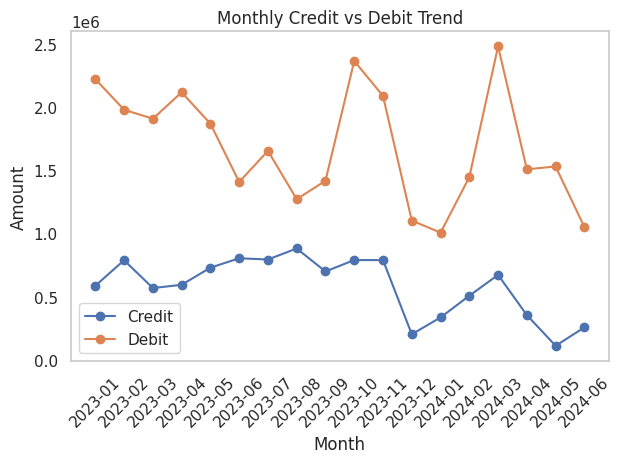

In [117]:
# ------------------------------------------------------------------------------------
# TASK--->2.2 -->Plot trends in total credits vs. debits over time.
# ------------------------------------------------------------------------------------

import matplotlib.pyplot as plt

# Monthly Credit vs Debit Trend
# Convert Period → string (for plotting)
dfm["month_str"] = dfm["MONTH"].astype(str)
#plt.figure()
plt.plot(dfm["month_str"], dfm["CREDIT"], marker='o', label="Credit")
plt.plot(dfm["month_str"], dfm["DEBIT"], marker='o', label="Debit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.title("Monthly Credit vs Debit Trend")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()




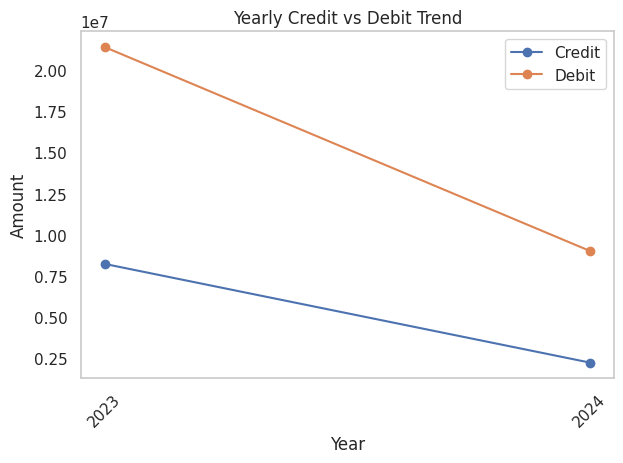

In [118]:
# Yearly Credit vs Debit Trend
dfy["year_str"] = dfy["YEAR"].astype(str)
plt.figure()
plt.plot(dfy["year_str"], dfy["CREDIT"], marker='o', label="Credit")
plt.plot(dfy["year_str"], dfy["DEBIT"], marker='o', label="Debit")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.title("Yearly Credit vs Debit Trend")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

In [119]:
# ------------------------------------------------------------------------------------
# TASK--->2.3--->Identify top and bottom performing accounts based on net inflow.
# ------------------------------------------------------------------------------------

# Define transaction categories
credit_types = ["DEPOSIT"]
debit_types = ["WITHDRAWAL", "PAYMENT", "TRANSFER"]

# Aggregate totals
account_summary = df.groupby(["AccountID", "TransactionType"])["TransactionAmount"] \
                    .sum().unstack(fill_value=0)
#account_summary = account_summary.reset_index()

#Compute Net Inflow
account_summary["TotalCredit"] = account_summary[credit_types].sum(axis=1)
account_summary["TotalDebit"] = account_summary[debit_types].sum(axis=1)
account_summary["NetInflow"] = account_summary["TotalCredit"] - account_summary["TotalDebit"]

top_accounts = account_summary.sort_values("NetInflow", ascending=False).head(5)
print("\nTop performing accounts:")
print(top_accounts[["TotalCredit", "TotalDebit", "NetInflow"]].round(2))
bottom_accounts = account_summary.sort_values("NetInflow", ascending=True).head(5)
print("\nBottom performing accounts:")
print(bottom_accounts[["TotalCredit", "TotalDebit", "NetInflow"]].round(2))



Top performing accounts:
TransactionType  TotalCredit  TotalDebit  NetInflow
AccountID                                          
ACC54589           225122.50        0.00  225122.50
ACC67713           196130.57     7058.79  189071.79
ACC74631           253027.51   102073.41  150954.10
ACC87602           162772.57    11912.00  150860.57
ACC22036           291395.48   146230.69  145164.80

Bottom performing accounts:
TransactionType  TotalCredit  TotalDebit  NetInflow
AccountID                                          
ACC18140                0.00   458219.21 -458219.21
ACC55331                0.00   448188.41 -448188.41
ACC51593                0.00   414370.12 -414370.12
ACC11285                0.00   373189.53 -373189.53
ACC81631            70661.59   413192.97 -342531.38


In [120]:
# ------------------------------------------------------------------------------------
# TASK--->2.4--->Identify and flag accounts as dormant or inactive if there is a
# gap of two months or more between consecutive transactions.
# ------------------------------------------------------------------------------------


df["Date"] = pd.to_datetime(df["TransactionDate"])
df = df.sort_values(["AccountID", "Date"])

df["PrevDate"] = df.groupby("AccountID")["Date"].shift(1)
df["GapDays"] = (df["Date"] - df["PrevDate"]).dt.days

df["DormantFlag"] = df["GapDays"] >= 60
dormant_accounts = df.groupby("AccountID")["DormantFlag"].any()

dormant_accounts = dormant_accounts.reset_index()
dormant_accounts["Status"] = dormant_accounts["DormantFlag"].apply(    lambda x: "Dormant" if x else "Active")

print("\nTotal accounts:")
print(df["AccountID"].nunique())

print("\nDormant accounts Summary:")
print(dormant_accounts["Status"].value_counts())

dormant_accounts = dormant_accounts[dormant_accounts["DormantFlag"] == True]
print("\nDormant accounts:")
print(dormant_accounts)





Total accounts:
194

Dormant accounts Summary:
Status
Dormant    164
Active      30
Name: count, dtype: int64

Dormant accounts:
    AccountID  DormantFlag   Status
1    ACC10996         True  Dormant
2    ACC11062         True  Dormant
3    ACC11188         True  Dormant
4    ACC11285         True  Dormant
6    ACC12182         True  Dormant
..        ...          ...      ...
188  ACC96868         True  Dormant
189  ACC97225         True  Dormant
190  ACC97411         True  Dormant
191  ACC99117         True  Dormant
193  ACC99549         True  Dormant

[164 rows x 3 columns]


In [121]:
#
#
# ==========================================================================================
# TASK 3: Customer Profile Building (20 Marks)
# ● Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis
# and rubrics. Do not forget to mention the rubric in the headings.
# ● Segment customers by average balance and transaction volume.
# ● Create profiles for:
# ○ High-net inflow accounts
# ○ High-frequency low-balance accounts
# ○ Accounts with negative or near-zero balances
# ==========================================================================================
#
#

In [122]:
# ------------------------------------------------------------------------------------
# TASK-->3.1---> Group accounts by activity levels: High, Medium, Low based on transaction frequency
# on your analysis and rubrics.
# Do not forget to mention the rubric in the headings.
# ------------------------------------------------------------------------------------

#Rubric--->
# Activity Level | Monthly Avg Transactions | Interpretation                        |
#--------------- | ------------------------ | ------------------------------------- |
# **High**       | ≥ 10                     | Highly engaged / frequent usage       |
# **Medium**     | 5 – 19                   | Moderate activity                     |
# **Low**        | < 5                      | Low engagement / inactive tendency    |


#Count transactions per account per month
monthly_txn = df.groupby(["AccountID", "Month"]).size().reset_index(name="TxnCount")

#Compute average monthly transactions per account
account_activity = monthly_txn.groupby("AccountID")["TxnCount"].mean().reset_index()
account_activity.rename(columns={"TxnCount": "AvgMonthlyTxn"}, inplace=True)

#Assign Activity Levels
def classify_activity(x):
    if x >= 20:
        return "High"
    elif x >= 5:
        return "Medium"
    else:
        return "Low"

account_activity["ActivityLevel"] = account_activity["AvgMonthlyTxn"].apply(classify_activity)

print("\nAccounts Activity Summary:")
print(account_activity["ActivityLevel"].value_counts())

print("\n"+account_activity.head().to_string())



Accounts Activity Summary:
ActivityLevel
Low    194
Name: count, dtype: int64

  AccountID  AvgMonthlyTxn ActivityLevel
0  ACC10117            1.0           Low
1  ACC10996            1.0           Low
2  ACC11062            1.0           Low
3  ACC11188            1.0           Low
4  ACC11285            1.0           Low


In [123]:
# ------------------------------------------------------------------------------------
# TASK-->3.2---> Segment customers by average balance and transaction volume.
# ------------------------------------------------------------------------------------

#Rubric--->
# Segment                | Avg Balance | Txn Volume | Interpretation                 |
# ---------------------- | ----------- | ---------- | ------------------------------ |
# **Premium Active**     | High        | High       | High-value + highly engaged    |
# **Premium Passive**    | High        | Low        | Wealthy but low activity       |
# **Mass Active**        | Low         | High       | Frequent users, lower balances |
# **Low Value**          | Low         | Low        | Low engagement + low value     |


txn_volume = df.groupby("AccountID").size().reset_index(name="TxnCount")
AvgBalance = df.groupby("AccountID")["AccountBalance"].mean().reset_index(name="AvgBalance").round(2)
#Merge Metrics
customer_seg = txn_volume.merge(AvgBalance, on="AccountID")

balance_threshold = customer_seg["AvgBalance"].median()
txn_threshold = customer_seg["TxnCount"].median()

#Assign Segments
def segment(row):
    if row["AvgBalance"] >= balance_threshold and row["TxnCount"] >= txn_threshold:
        return "Premium Active"
    elif row["AvgBalance"] >= balance_threshold:
        return "Premium Passive"
    elif row["TxnCount"] >= txn_threshold:
        return "Mass Active"
    else:
        return "Low Value"

customer_seg["Segment"] = customer_seg.apply(segment, axis=1)
customer_seg = customer_seg.sort_values(
    by=["TxnCount", "AvgBalance"],
    ascending=[False, False]
)


In [124]:
print(customer_seg.head().to_string())

    AccountID  TxnCount  AvgBalance         Segment
58   ACC32627        10    81299.56  Premium Active
103  ACC51593        10    75116.30  Premium Active
85   ACC45907        10    53323.05     Mass Active
51   ACC29646         9    93471.20  Premium Active
110  ACC55331         9    85940.53  Premium Active


In [125]:
# ------------------------------------------------------------------------------------
# TASK-->3.3--->Create profiles for:
#○ High-net inflow accounts
#○ High-frequency low-balance accounts
#○ Accounts with negative or near-zero balances
# ------------------------------------------------------------------------------------


#Rubric--->
# Condition                    | Logic                             |
# ---------------------------- | --------------------------------- |
# NetInflow ≥ 75th percentile  | High inflow                       |
# TxnCount ≥ 75th percentile  &| High frequency low-balance        |
# AvgBalance ≤ 25th percentile                                     |
# AvgBalance ≤ 1,000           | Negative or near-zero balances    |

customer_profile = (
    df.groupby("AccountID")
      .agg(
          NetInflow=("TransactionAmount", "sum"),   # or precomputed
          TxnCount=("TransactionAmount", "count"),
          AvgBalance=("AccountBalance", "mean")
      )
      .reset_index()
)
#high_inflow
inflow_threshold = customer_profile["NetInflow"].quantile(0.75)
high_inflow = customer_profile[
    customer_profile["NetInflow"] >= inflow_threshold
]

#high_freq_low_bal
txn_threshold = customer_profile["TxnCount"].quantile(0.75)
balance_threshold = customer_profile["AvgBalance"].quantile(0.25)
high_freq_low_bal = customer_profile[
    (customer_profile["TxnCount"] >= txn_threshold) &
    (customer_profile["AvgBalance"] <= balance_threshold)
]

#Negative or near-zero balances
low_balance_accounts = customer_profile[
    customer_profile["AvgBalance"] <= 1000   # adjust threshold
]

#Combine Profiles
def profile_tag(row):
    if row["NetInflow"] >= inflow_threshold:
        return "High Net Inflow"
    elif row["TxnCount"] >= txn_threshold and row["AvgBalance"] <= balance_threshold:
        return "High Freq Low Balance"
    elif row["AvgBalance"] <= 1000:
        return "Low / Negative Balance"
    else:
        return "Negative or Near-Zero Balances"

customer_profile["Profile"] = customer_profile.apply(profile_tag, axis=1)

#Distribution
customer_profile["Profile"].value_counts()

,count
Profile,
Negative or Near-Zero Balances,140
High Net Inflow,49
High Freq Low Balance,5


In [126]:
#
#
# ==========================================================================================
# Task 4: Financial Risk Identification (10 Marks)
# ● Track accounts with frequent large withdrawals or overdrafts.
# ● Calculate balance volatility using standard deviation or coefficient of variation.
# ● Use IQR or z-score methods to detect anomalies.
# ● Highlight customers with irregular or suspicious transaction behavior.
# ==========================================================================================
#
#

In [127]:
# ------------------------------------------------------------------------------------
# TASK-->4.1-->Track accounts with frequent large withdrawals or overdrafts.
# ------------------------------------------------------------------------------------

#Rubric--->
#Large Withdrawal Criteria
#Amount ≥ 90th percentile of withdrawals (data-driven)

#Frequent Condition
#Count of large withdrawals ≥ N (e.g., 3 in period)

#Overdraft Criteria
#Balance < 0

#Filter withdrawals
#withdrawals = df[df["TransactionType"].isin(["WITHDRAWAL", "PAYMENT", "TRANSFER"])]
withdrawals = df[df["TransactionType"].isin(["WITHDRAWAL","PAYMENT","TRANSFER"])].copy()

# keep only positive withdrawal amounts
wd_nonzero = withdrawals[withdrawals["TransactionAmount"] > 0].copy()
large_wd_threshold = wd_nonzero["TransactionAmount"].quantile(0.90)
withdrawals["LargeWithdrawal"] = withdrawals["TransactionAmount"] >= large_wd_threshold

#Aggregate Per Account
wd_summary = withdrawals.groupby("AccountID").agg(
    LargeWithdrawalCount=("LargeWithdrawal", "sum"),
    TotalWithdrawals=("TransactionAmount", "count"),
    TotalWithdrawalAmount=("TransactionAmount", "sum")
).reset_index()
wd_summary["TotalWithdrawalAmount"] = wd_summary["TotalWithdrawalAmount"].round(2)
print("\nWithdrawal Summary:")
print(wd_summary.sort_values(by=["TotalWithdrawals", "TotalWithdrawalAmount"],ascending=[False, False]))

#Detect Overdraft Behavior
overdraft = df[df["AccountBalance"] < 0]


overdraft_summary = overdraft.groupby("AccountID").agg(
    OverdraftCount=("AccountBalance", "count"),
    MinBalance=("AccountBalance", "min")
).reset_index()
overdraft_summary["MinBalance"] = overdraft_summary["MinBalance"].round(2)
print("\nOverdraft Summary:")
print(overdraft_summary.sort_values(by=["OverdraftCount", "MinBalance"],ascending=[False, True]))




Withdrawal Summary:
    AccountID  LargeWithdrawalCount  TotalWithdrawals  TotalWithdrawalAmount
100  ACC51593                     1                10              414370.12
105  ACC55331                     2                 9              448188.41
49   ACC29646                     0                 8              377872.96
112  ACC60432                     0                 8              257054.08
16   ACC18140                     0                 7              458219.21
..        ...                   ...               ...                    ...
15   ACC18057                     0                 1               26690.67
66   ACC37688                     0                 1               25736.95
163  ACC87602                     0                 1               11912.00
125  ACC67713                     0                 1                7058.79
42   ACC28305                     0                 1                -739.39

[188 rows x 4 columns]

Overdraft Summary:
  AccountID

In [128]:
# ------------------------------------------------------------------------------------
# ASK-->4.2--> Calculate balance volatility using standard deviation or coefficient of variation.
# ------------------------------------------------------------------------------------


volatility = df.groupby("AccountID").agg(
    AvgBalance=("AccountBalance", "mean"),
    StdBalance=("AccountBalance", "std")
).reset_index()

import numpy as np
volatility["CV"] = np.where(
    volatility["AvgBalance"] != 0,
    volatility["StdBalance"] / volatility["AvgBalance"],
    np.nan
)

float_cols = volatility.select_dtypes(include="float").columns
volatility[float_cols] = volatility[float_cols].round(2)

print("\nBalance Volatility Summary:")
print(volatility.sort_values(by="CV", ascending=False))


Balance Volatility Summary:
    AccountID  AvgBalance  StdBalance    CV
98   ACC49774    47341.42    67777.81  1.43
73   ACC39529    75349.81    87925.61  1.17
155  ACC78589    70449.55    74986.23  1.06
119  ACC61827    46163.40    48703.94  1.06
150  ACC77638    47234.38    46413.05  0.98
..        ...         ...         ...   ...
94   ACC49180    91832.49         NaN   NaN
95   ACC49364    64526.97         NaN   NaN
146  ACC76597    73186.96         NaN   NaN
162  ACC82947    73073.64         NaN   NaN
168  ACC87006    82533.44         NaN   NaN

[194 rows x 4 columns]


In [129]:
# --------------------------------------------------------------------------------
# ASK-->4.3--> Use IQR or z-score methods to detect anomalies.
# --------------------------------------------------------------------------------

# IQR Method
# IQR=Q3−Q1
# Outliers:   x<Q1−1.5×IQR or x>Q3+1.5×IQR

Q1 = df["AccountBalance"].quantile(0.25)
Q3 = df["AccountBalance"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_df = pd.DataFrame({
    "AccountID": df["AccountID"],
    "AccountBalance": df["AccountBalance"],
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "LowerBound": lower_bound,
    "UpperBound": upper_bound
})

iqr_df["IQR_Outlier"] = (
    (iqr_df["AccountBalance"] < lower_bound) |
    (iqr_df["AccountBalance"] > upper_bound)
)

float_cols = iqr_df.select_dtypes(include="float").columns
iqr_df[float_cols] = iqr_df[float_cols].round(2)

print("\nIQR Outlier Summary:")
print(iqr_df["IQR_Outlier"].value_counts())

print("\nIQR Outlier Details:")
print(iqr_df[iqr_df["IQR_Outlier"]].to_string())



IQR Outlier Summary:
IQR_Outlier
False    787
True      13
Name: count, dtype: int64

IQR Outlier Details:
    AccountID  AccountBalance        Q1        Q3       IQR  LowerBound  UpperBound  IQR_Outlier
771  ACC11285       162335.78  53547.22  95584.41  42037.19    -9508.57    158640.2         True
629  ACC12182       159827.66  53547.22  95584.41  42037.19    -9508.57    158640.2         True
151  ACC18177       166805.96  53547.22  95584.41  42037.19    -9508.57    158640.2         True
381  ACC21719       162192.90  53547.22  95584.41  42037.19    -9508.57    158640.2         True
105  ACC28612       164902.94  53547.22  95584.41  42037.19    -9508.57    158640.2         True
228  ACC29007       159321.43  53547.22  95584.41  42037.19    -9508.57    158640.2         True
568  ACC30852       -13018.40  53547.22  95584.41  42037.19    -9508.57    158640.2         True
62   ACC33287       183836.93  53547.22  95584.41  42037.19    -9508.57    158640.2         True
121  ACC50817      

In [130]:
# --------------------------------------------------------------------------------
# ASK-->4.4--> Highlight customers with irregular or suspicious transaction behavior.
# --------------------------------------------------------------------------------

# Rubric--->
# Signal                    | Condition                           | Why it matters              |
# ------------------------- | ----------------------------------- | --------------------------- |
# Large withdrawals         | ≥ 90th percentile amounts, frequent | potential cash-out/fraud    |
# High balance volatility   | CV > 0.5                            | unstable cash flow          |
# Negative / low net inflow | NetInflow < 0                       | sustained outflow           |
# IQR outliers              | any outlier in balance/amount       | abnormal spikes             |
# Dormancy gaps             | ≥ 60 days gaps                      | unusual inactivity patterns |



import pandas as pd
import numpy as np

df["Date"] = pd.to_datetime(df["TransactionDate"])

# 1) Net inflow (define credits/debits per your schema)
credit_types = ["DEPOSIT"]
debit_types = ["WITHDRAWAL", "PAYMENT", "TRANSFER"]

tmp = df.copy()
tmp["Credit"] = np.where(tmp["TransactionType"].isin(credit_types), tmp["TransactionAmount"], 0)
tmp["Debit"]  = np.where(tmp["TransactionType"].isin(debit_types),  tmp["TransactionAmount"], 0)

net = tmp.groupby("AccountID").agg(
    TotalCredit=("Credit","sum"),
    TotalDebit=("Debit","sum"),
    TxnCount=("TransactionAmount","count")
).reset_index()

net["NetInflow"] = net["TotalCredit"] - net["TotalDebit"]


# 2) Volatility (STD + CV)
vol = df.groupby("AccountID").agg(
    AvgBalance=("AccountBalance","mean"),
    StdBalance=("AccountBalance","std")
).reset_index()

vol["CV"] = np.where(vol["AvgBalance"] != 0,
                     vol["StdBalance"] / vol["AvgBalance"],
                     np.nan)



# 3) Large withdrawals (90th percentile, non-zero)
wd = df[df["TransactionType"].isin(debit_types)].copy()
wd["TransactionAmount"] = pd.to_numeric(wd["TransactionAmount"], errors="coerce")

thr = wd.loc[wd["TransactionAmount"] > 0, "TransactionAmount"].quantile(0.90)
wd["LargeWD"] = wd["TransactionAmount"] >= thr

wd_sum = wd.groupby("AccountID").agg(
    LargeWithdrawalCount=("LargeWD","sum")
).reset_index()


# 4) IQR outlier flag on balance (global example)
Q1 = df["AccountBalance"].quantile(0.25)
Q3 = df["AccountBalance"].quantile(0.75)
IQR = Q3 - Q1
lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR

iqr_flag = df.assign(IQR_Outlier=lambda x: (x["AccountBalance"] < lb) | (x["AccountBalance"] > ub)) \
             .groupby("AccountID")["IQR_Outlier"].any() \
             .reset_index()


# 5) Dormancy (max gap ≥ 60 days)
df = df.sort_values(["AccountID","Date"])
gaps = df.groupby("AccountID")["Date"].diff().dt.days
gap_flag = gaps.groupby(df["AccountID"]).max().ge(60).reset_index(name="DormantGap")

risk = (net
        .merge(vol, on="AccountID", how="left")
        .merge(wd_sum, on="AccountID", how="left")
        .merge(iqr_flag, on="AccountID", how="left")
        .merge(gap_flag, on="AccountID", how="left")
        .fillna({
            "LargeWithdrawalCount": 0,
            "CV": 0,
            "IQR_Outlier": False,
            "DormantGap": False
        }))


risk["SuspiciousFlag"] = np.where(
    (risk["LargeWithdrawalCount"] >= 3) |   # frequent large withdrawals
    (risk["CV"] > 0.5) |                   # high volatility
    (risk["NetInflow"] < 0) |              # net outflow
    (risk["IQR_Outlier"]) |                # anomalies
    (risk["DormantGap"]),                 # long inactivity gaps
    "Suspicious",
    "Normal"
)

summary_df = risk[[
    "AccountID",
    "NetInflow",
    "TxnCount",
    "AvgBalance",
    "CV",
    "LargeWithdrawalCount",
    "IQR_Outlier",
    "DormantGap",
    "SuspiciousFlag"
]].copy()

float_cols = summary_df.select_dtypes(include="float").columns
summary_df[float_cols] = summary_df[float_cols].round(2)

print("\nSuspicious Account Summary:")
print(summary_df["SuspiciousFlag"].value_counts())

print("\n\nSuspicious Account Details:")
print(
    summary_df[summary_df["SuspiciousFlag"] == "Suspicious"]
    .head(10)
    .to_string()
)



Suspicious Account Summary:
SuspiciousFlag
Suspicious    189
Normal          5
Name: count, dtype: int64


Suspicious Account Details:
   AccountID  NetInflow  TxnCount  AvgBalance    CV  LargeWithdrawalCount  IQR_Outlier  DormantGap SuspiciousFlag
0   ACC10117  -56317.92         1    90780.26  0.00                   0.0        False       False     Suspicious
1   ACC10996  124107.38         4    64046.57  0.47                   0.0        False        True     Suspicious
2   ACC11062 -142721.04         4    62784.10  0.60                   1.0        False        True     Suspicious
3   ACC11188 -116557.95         3    80558.93  0.42                   0.0        False        True     Suspicious
4   ACC11285 -373189.53         6    95745.55  0.44                   0.0         True        True     Suspicious
6   ACC12182   76190.03         4   111954.46  0.37                   0.0         True        True     Suspicious
7   ACC12334  -15159.69         2    77237.60  0.26               

In [131]:
#
#
# ==========================================================================================
# Task 5: Visualisation (10 Marks)
# ● Conduct extensive exploratory data analysis with attractive visualizations for your findings
# ==========================================================================================
#
#

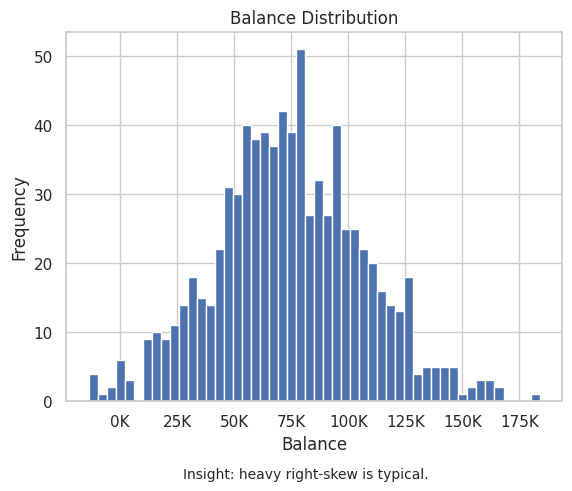

In [132]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)
sns.set_theme(style="whitegrid")


plt.figure()
df["AccountBalance"].hist(bins=50)

plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

plt.title("Balance Distribution")
plt.xlabel("Balance"); plt.ylabel("Frequency")
plt.figtext(
    0.5, -0.05,   # (x, y) position → center bottom
    "Insight: heavy right-skew is typical.",
    ha="center",
    fontsize=10,
    wrap=True
)

plt.show()




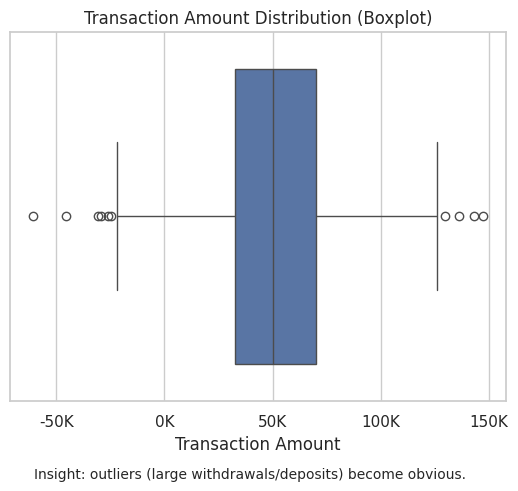

In [133]:
plt.figure()
sns.boxplot(x=df["TransactionAmount"])
plt.title("Transaction Amount Distribution (Boxplot)")
plt.xlabel("Transaction Amount")
#plt,plt.ylabel("Frequency")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)
plt.figtext(
    0.5, -0.05,   # (x, y) position → center bottom
    "Insight: outliers (large withdrawals/deposits) become obvious.",
    ha="center",
    fontsize=10,
    wrap=True
)
plt.show()

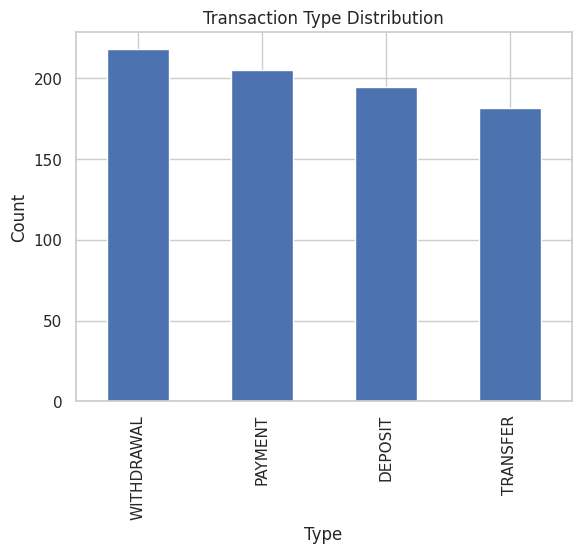

In [134]:
plt.figure()
df["TransactionType"].value_counts().plot(kind="bar")
plt.title("Transaction Type Distribution")
plt.xlabel("Type"); plt.ylabel("Count")
plt.show()

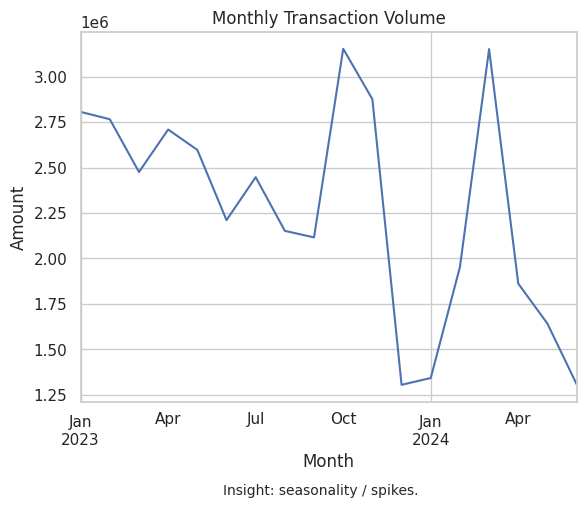

In [135]:
df["Month"] = pd.to_datetime(df["Date"]).dt.to_period("M")
monthly = df.groupby("Month")["TransactionAmount"].sum()

plt.figure()
monthly.plot()
plt.title("Monthly Transaction Volume")
plt.xlabel("Month"); plt.ylabel("Amount")
plt.figtext(
    0.5, -0.08,   # (x, y) position → center bottom
    "\nInsight: seasonality / spikes.",
    ha="center",
    fontsize=10,
    wrap=True
)
plt.show()

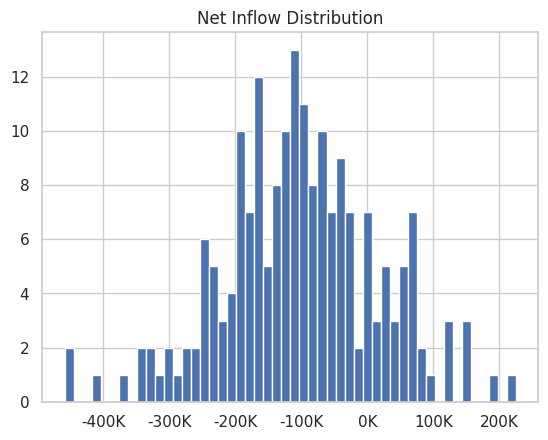

In [136]:
plt.figure()
summary_df["NetInflow"].hist(bins=50)
plt.title("Net Inflow Distribution")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)
plt.show()




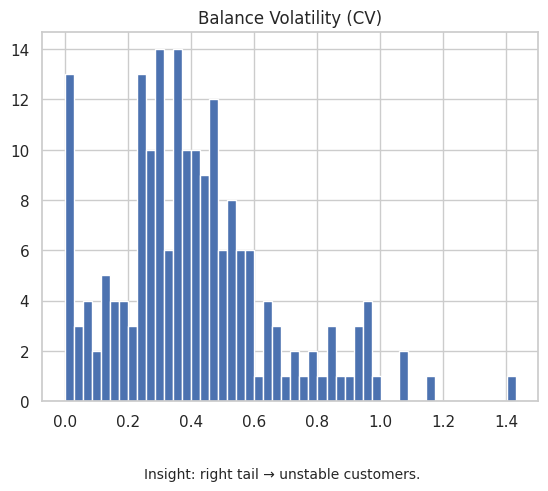

In [137]:
plt.figure()
summary_df["CV"].hist(bins=50)
plt.title("Balance Volatility (CV)")
plt.figtext(
    0.5, -0.05,   # (x, y) position → center bottom
    "Insight: right tail → unstable customers.",
    ha="center",
    fontsize=10,
    wrap=True
)
plt.show()

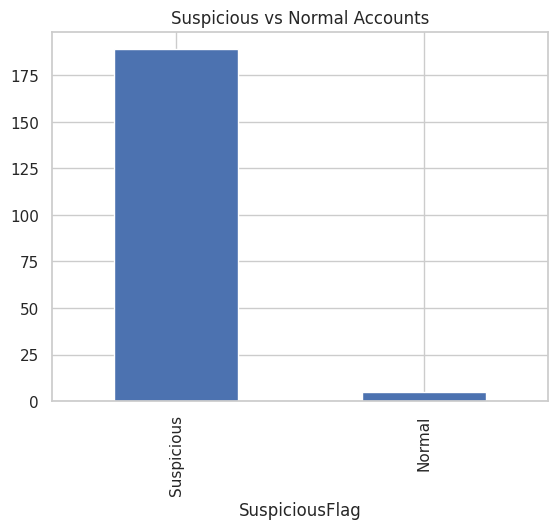

In [138]:
plt.figure()
summary_df["SuspiciousFlag"].value_counts().plot(kind="bar")
plt.title("Suspicious vs Normal Accounts")
plt.show()

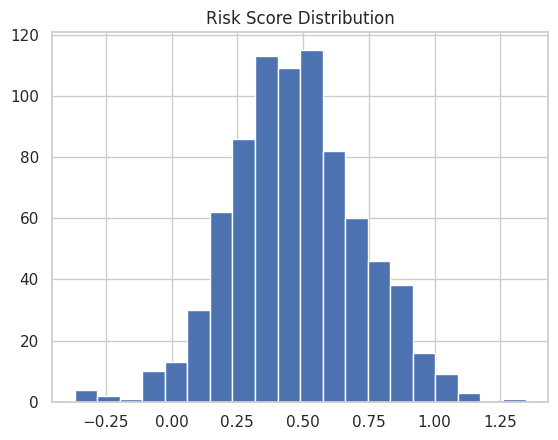

In [139]:
plt.figure()
df["RiskScore"].hist(bins=20)
plt.title("Risk Score Distribution")
plt.show()

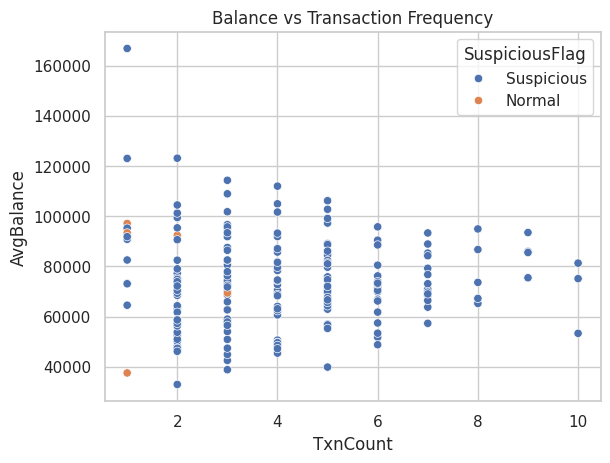

In [140]:
plt.figure()
sns.scatterplot(
    data=summary_df,
    x="TxnCount",
    y="AvgBalance",
    hue="SuspiciousFlag"
)
plt.title("Balance vs Transaction Frequency")
plt.show()

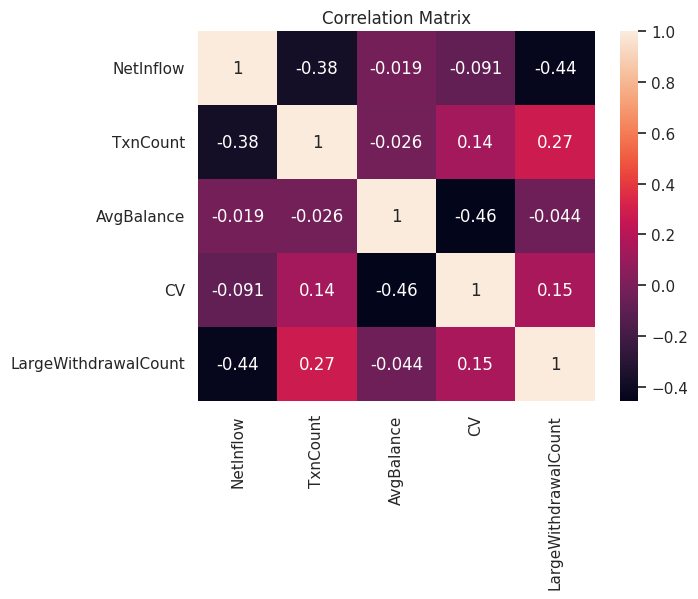

In [141]:
plt.figure()
sns.heatmap(summary_df.select_dtypes("number").corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

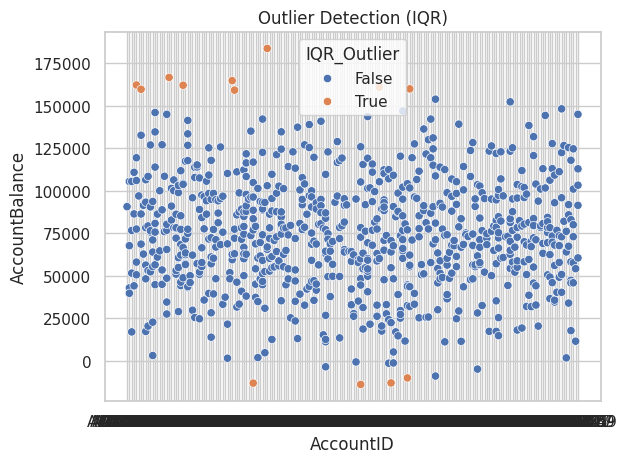

In [142]:
plt.figure()
sns.scatterplot(
    data=iqr_df,
    x="AccountID",
    y="AccountBalance",
    hue="IQR_Outlier"
)
plt.title("Outlier Detection (IQR)")
plt.show()

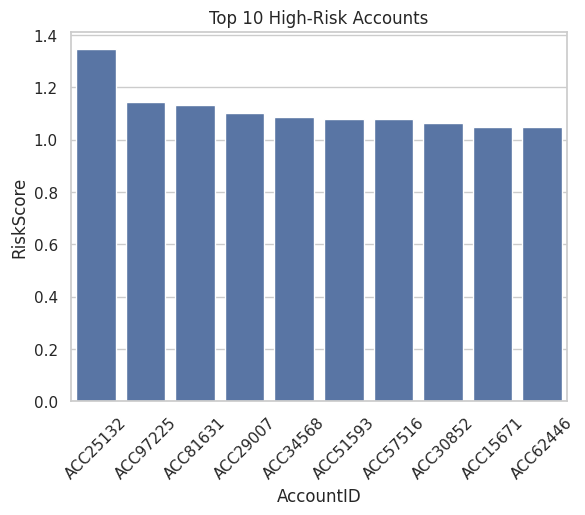

In [143]:
top_risk = df.sort_values("RiskScore", ascending=False).head(10)

plt.figure()
sns.barplot(data=top_risk, x="AccountID", y="RiskScore")
plt.title("Top 10 High-Risk Accounts")
plt.xticks(rotation=45)
plt.show()

In [144]:
# ----------------------------------------------------------------------
# Key Findings
# Skewed balance distribution → few high-value accounts dominate
# High CV accounts → unstable → risk/churn candidates
# Frequent large withdrawals → potential fraud signals
# Suspicious segment % → overall risk exposure
# Strong correlations → e.g., TxnCount vs NetInflow
# ----------------------------------------------------------------------

In [145]:
#
#
# ==========================================================================================
# Task 6: Hypothesis Testing (10 Marks)
# ● Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.
# ● Conduct hypothesis testing based on segmentation.
# ==========================================================================================
#
#

In [146]:

# Hypotheses
# Let:
# μH = mean balance of high-volume accounts
# μL = mean balance of low-volume accounts

# Null Hypothesis (H₀)
# μH=μL	​

# Alternative Hypothesis (H₁)
# μH>μL
# One-tailed test (you expect high-volume to be higher)​
#


#Define threshold
account_stats = df.groupby("AccountID").agg(
    TxnCount=("TransactionAmount", "count"),
    AvgBalance=("AccountBalance", "mean")
).reset_index()

threshold = account_stats["TxnCount"].median()
account_stats["VolumeSegment"] = np.where(
    account_stats["TxnCount"] >= threshold,
    "High",
    "Low"
)

# Split Data
high_group = account_stats[account_stats["VolumeSegment"] == "High"]["AvgBalance"]
low_group  = account_stats[account_stats["VolumeSegment"] == "Low"]["AvgBalance"]

# Perform Hypothesis Test
# Use Independent T-Test
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(high_group, low_group, alternative="greater")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

#Decision Rule
# : p_value > alpha : Not significant. Any difference could just be random "noise" in the data.
alpha = 0.05
if p_value < alpha:
    print("T TEST--> Reject H0 → High-volume accounts have higher balances")
else:
    print("T TEST--> Fail to reject H0 → No significant difference. Assumption Failed.")

#
# Assumptions Failed → Lets try "non-parametric" version of the T-test
# --> use it when you can't assume your data follows a normal (bell-shaped)
# distribution—which is very common with transaction counts or financial data.
#

from scipy.stats import mannwhitneyu
u_stat, p_value = mannwhitneyu(high_group, low_group, alternative="greater")
print(f"\nU-statistic: {u_stat:.4f}")
print(f"P-value: {p_value:.4f}")

#Decision Rule
# : p_value > alpha : Not significant. Any difference could just be random "noise" in the data.
if p_value < alpha:
    print("U TETS--> Reject H0 → High-volume accounts have higher balances")
else:
    print("U TEST--> Fail to reject H0 → No significant difference. Assumption Failed.")


print("\nFinal Insight : Difference is not Real Its just random noise.\n\nYou cannot say that the 'High Activity' group has a higher CV \nor different behavior than the 'Low Activity' group. \nStatistically, they look essentially the same.")


T-statistic: -0.1226
P-value: 0.5487
T TEST--> Fail to reject H0 → No significant difference. Assumption Failed.

U-statistic: 4722.0000
P-value: 0.4093
U TEST--> Fail to reject H0 → No significant difference. Assumption Failed.

Final Insight : Difference is not Real Its just random noise.

You cannot say that the 'High Activity' group has a higher CV 
or different behavior than the 'Low Activity' group. 
Statistically, they look essentially the same.


In [147]:
#
#
# ==========================================================================================
# Task 7: Video Presentation
# ==========================================================================================
#
#

# Video link
# https://drive.google.com/file/d/1-xYWjsRDMBV8QmDE0nQY8z04ieTrgf21/view?usp=sharing